# Fund Performance Analytics

## Day 4 - Task 1: Daily Returns Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
print(nav.columns)

print(nav.dtypes)

print(nav.head())

Index(['amfi_code', 'date', 'nav'], dtype='str')
amfi_code      int64
date             str
nav          float64
dtype: object
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

In [5]:
print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


## Step 1: Calculate Daily Returns

### Objective
Daily return measures the percentage change in NAV from one trading day to the next.

**Formula:**

Daily Return = (Today's NAV / Yesterday's NAV) - 1

This metric is the foundation for calculating CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and other performance metrics.

In [6]:
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

print()

print(nav["daily_return"].describe())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


### Insight 1

- Daily returns were calculated for each mutual fund scheme using consecutive NAV values.
- The first observation for each fund has a missing daily return because there is no previous NAV available for comparison.
- The average daily return across all funds is positive, indicating an overall upward trend during the analysis period.
- Daily returns will be used in subsequent calculations such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

# Task 2: Compound Annual Growth Rate (CAGR)

In [10]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [11]:
cagr_data = []

for amfi_code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    start_date = group.iloc[0]["date"]
    end_date = group.iloc[-1]["date"]

    years = (end_date - start_date).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_data.append({
        "amfi_code": amfi_code,
        "start_date": start_date,
        "end_date": end_date,
        "years": round(years, 2),
        "CAGR (%)": round(cagr, 2)
    })

cagr_df = pd.DataFrame(cagr_data)

cagr_df.head()

,amfi_code,start_date,end_date,years,CAGR (%)
0,100016,2022-01-03,2026-05-29,4.4,2.64
1,100025,2022-01-03,2026-05-29,4.4,4.46
2,100033,2022-01-03,2026-05-29,4.4,30.12
3,101206,2022-01-03,2026-05-29,4.4,23.54
4,101207,2022-01-03,2026-05-29,4.4,7.94


In [12]:
print(cagr_df.head())

print()

print(cagr_df.describe())

   amfi_code start_date   end_date  years  CAGR (%)
0     100016 2022-01-03 2026-05-29    4.4      2.64
1     100025 2022-01-03 2026-05-29    4.4      4.46
2     100033 2022-01-03 2026-05-29    4.4     30.12
3     101206 2022-01-03 2026-05-29    4.4     23.54
4     101207 2022-01-03 2026-05-29    4.4      7.94

           amfi_code           start_date             end_date  years  \
count      40.000000                   40                   40   40.0   
mean   120247.000000  2022-01-03 00:00:00  2026-05-29 00:00:00    4.4   
min    100016.000000  2022-01-03 00:00:00  2026-05-29 00:00:00    4.4   
25%    118632.750000  2022-01-03 00:00:00  2026-05-29 00:00:00    4.4   
50%    119551.500000  2022-01-03 00:00:00  2026-05-29 00:00:00    4.4   
75%    120842.250000  2022-01-03 00:00:00  2026-05-29 00:00:00    4.4   
max    149324.000000  2022-01-03 00:00:00  2026-05-29 00:00:00    4.4   
std     14534.998667                  NaN                  NaN    0.0   

        CAGR (%)  
count  40.

### Insight 2

- CAGR was calculated for all 40 mutual fund schemes using the first and last available NAV values.
- The dataset covers approximately 4.4 years of NAV history (January 2022 to May 2026).
- CAGR provides the average annual growth rate of each mutual fund over the available investment period.
- This metric enables fair comparison of long-term fund performance regardless of the total return.

# Task 3: Sharpe Ratio Calculation
Sharpe Ratio = (Average Return − Risk-Free Rate) / Standard Deviation of Returns

In this project:
- Risk-Free Rate = 6.5% per year
- Daily returns are annualized using 252 trading days.

In [15]:
risk_free_rate = 0.065  # 6.5% annual risk-free rate

sharpe_data = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_daily_return = returns.mean()

    std_daily_return = returns.std()


    annual_return = avg_daily_return * 252
    annual_volatility = std_daily_return * np.sqrt(252)

    if annual_volatility != 0:
        sharpe = (annual_return - risk_free_rate) / annual_volatility
    else:
        sharpe = np.nan

    sharpe_data.append({
        "amfi_code": amfi_code,
        "Annual Return": round(annual_return, 4),
        "Annual Volatility": round(annual_volatility, 4),
        "Sharpe Ratio": round(sharpe, 4) if pd.notna(sharpe) else np.nan
    })

sharpe_df = pd.DataFrame(sharpe_data)

sharpe_df.head()

,amfi_code,Annual Return,Annual Volatility,Sharpe Ratio
0,100016,0.0357,0.1455,-0.2015
1,100025,0.0429,0.0391,-0.5671
2,100033,0.2721,0.1894,1.0937
3,101206,0.2146,0.1457,1.0272
4,101207,0.1070,0.2580,0.1627


In [16]:
print(sharpe_df.head())

print()

print(sharpe_df.describe())

   amfi_code  Annual Return  Annual Volatility  Sharpe Ratio
0     100016         0.0357             0.1455       -0.2015
1     100025         0.0429             0.0391       -0.5671
2     100033         0.2721             0.1894        1.0937
3     101206         0.2146             0.1457        1.0272
4     101207         0.1070             0.2580        0.1627

           amfi_code  Annual Return  Annual Volatility  Sharpe Ratio
count      40.000000      40.000000          40.000000     40.000000
mean   120247.000000       0.159023           0.149443      0.537220
std     14534.998667       0.087571           0.066751      0.573688
min    100016.000000       0.027700           0.004900     -0.815600
25%    118632.750000       0.068825           0.138450      0.064700
50%    119551.500000       0.163200           0.145600      0.647050
75%    120842.250000       0.221250           0.181850      1.005275
max    149324.000000       0.302700           0.258000      1.448300


### Insight 3

- The Sharpe Ratio was calculated for each mutual fund using annualized returns and annualized volatility.
- A higher Sharpe Ratio indicates better risk-adjusted performance.
- Funds with higher returns and lower volatility achieved superior Sharpe Ratios.
- This metric helps investors compare funds based on both return and risk rather than return alone.

# Task 4: Sortino Ratio Calculation

In [ ]:
risk_free_rate = 0.065  # 6.5% annual risk-free rate

sortino_data = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_daily_return = returns.mean()

    annual_return = avg_daily_return * 252

    downside_returns = returns[returns < 0]

    downside_deviation = downside_returns.std() * np.sqrt(252)

    # Calculate Sortino Ratio safely
    if pd.notna(downside_deviation) and downside_deviation != 0:
        sortino = (annual_return - risk_free_rate) / downside_deviation
    else:
        sortino = np.nan

    sortino_data.append({
        "amfi_code": amfi_code,
        "Annual Return": round(annual_return, 4),
        "Downside Deviation": round(downside_deviation, 4) if pd.notna(downside_deviation) else np.nan,
        "Sortino Ratio": round(sortino, 4) if pd.notna(sortino) else np.nan
    })

sortino_df = pd.DataFrame(sortino_data)

sortino_df.head()

,amfi_code,Annual Return,Downside Deviation,Sortino Ratio
0,100016,0.0357,0.0835,-0.3510
1,100025,0.0429,0.0235,-0.9418
2,100033,0.2721,0.1132,1.8291
3,101206,0.2146,0.0832,1.7996
4,101207,0.1070,0.1517,0.2766


In [18]:
print(sortino_df.head())

print()

print(sortino_df.describe())

   amfi_code  Annual Return  Downside Deviation  Sortino Ratio
0     100016         0.0357              0.0835        -0.3510
1     100025         0.0429              0.0235        -0.9418
2     100033         0.2721              0.1132         1.8291
3     101206         0.2146              0.0832         1.7996
4     101207         0.1070              0.1517         0.2766

           amfi_code  Annual Return  Downside Deviation  Sortino Ratio
count      40.000000      40.000000           40.000000      40.000000
mean   120247.000000       0.159023            0.087447       0.923340
std     14534.998667       0.087571            0.039575       1.005403
min    100016.000000       0.027700            0.002300      -1.681000
25%    118632.750000       0.068825            0.078050       0.106675
50%    119551.500000       0.163200            0.085850       1.116950
75%    120842.250000       0.221250            0.108575       1.727750
max    149324.000000       0.302700            0.1517

### Insight 4

- The Sortino Ratio evaluates fund performance using only downside risk.
- Unlike the Sharpe Ratio, it ignores positive price movements and focuses only on harmful volatility.
- Funds with higher Sortino Ratios provide better returns while minimizing downside risk.
- This metric is especially useful for long-term investors who are more concerned about losses than gains.

# Task 5: Alpha and Beta Calculation

In [19]:
from scipy.stats import linregress

In [20]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [22]:
print(benchmark.columns)

print(benchmark.dtypes)

print(benchmark.head())

Index(['date', 'index_name', 'close_value'], dtype='str')
date               str
index_name         str
close_value    float64
dtype: object
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [23]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(benchmark.dtypes)

date           datetime64[us]
index_name                str
close_value           float64
dtype: object


In [24]:
benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [25]:
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"][
    ["date", "benchmark_return"]
]

merged = pd.merge(
    nav,
    nifty50,
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,0.011253
2,100016,2022-01-05,521.7239,0.012865,0.008220
3,100016,2022-01-06,515.7880,-0.011377,0.002437
4,100016,2022-01-07,515.1639,-0.001210,-0.006676


In [26]:
from scipy.stats import linregress

alpha_beta = []

for amfi_code, group in merged.groupby("amfi_code"):

    group = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(group) > 2:

        slope, intercept, r_value, p_value, std_err = linregress(
            group["benchmark_return"],
            group["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": amfi_code,
            "Alpha": round(intercept * 252, 4),  # Annualized Alpha
            "Beta": round(slope, 4)
        })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.0362,-0.0259
1,100025,0.0432,-0.0162
2,100033,0.2723,-0.0112
3,101206,0.2139,0.0338
4,101207,0.1082,-0.0599


In [28]:
print(alpha_beta_df.head())
print(alpha_beta_df.describe())

   amfi_code   Alpha    Beta
0     100016  0.0362 -0.0259
1     100025  0.0432 -0.0162
2     100033  0.2723 -0.0112
3     101206  0.2139  0.0338
4     101207  0.1082 -0.0599
           amfi_code      Alpha       Beta
count      40.000000  40.000000  40.000000
mean   120247.000000   0.159002   0.001070
std     14534.998667   0.087390   0.035891
min    100016.000000   0.028900  -0.061500
25%    118632.750000   0.069150  -0.016500
50%    119551.500000   0.162300  -0.001500
75%    120842.250000   0.221025   0.013225
max    149324.000000   0.301100   0.132600


In [ ]:
alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)

alpha_beta.csv saved successfully!


### Insight 5

- Alpha and Beta were calculated by comparing each mutual fund's daily returns with the NIFTY50 benchmark returns.
- Beta measures the sensitivity of a fund to overall market movements.
- Alpha measures the fund's excess return after accounting for market performance.
- Positive Alpha indicates outperformance relative to the benchmark, while Beta values greater than 1 indicate higher market sensitivity.

# Task 6: Maximum Drawdown Calculation

In [29]:
drawdown_data = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Maximum Drawdown
    max_drawdown = group["drawdown"].min()

    drawdown_data.append({
        "amfi_code": amfi_code,
        "Maximum Drawdown": round(max_drawdown, 4)
    })

drawdown_df = pd.DataFrame(drawdown_data)

drawdown_df.head()

,amfi_code,Maximum Drawdown
0,100016,-0.2473
1,100025,-0.0431
2,100033,-0.1622
3,101206,-0.1129
4,101207,-0.3545


In [30]:
print(drawdown_df.head())

print()

print(drawdown_df.describe())

   amfi_code  Maximum Drawdown
0     100016           -0.2473
1     100025           -0.0431
2     100033           -0.1622
3     101206           -0.1129
4     101207           -0.3545

           amfi_code  Maximum Drawdown
count      40.000000         40.000000
mean   120247.000000         -0.178728
std     14534.998667          0.112682
min    100016.000000         -0.525700
25%    118632.750000         -0.215925
50%    119551.500000         -0.163100
75%    120842.250000         -0.117625
max    149324.000000         -0.001000


### Insight 6

- Maximum Drawdown was calculated using the running maximum NAV for each mutual fund.
- It represents the largest percentage decline from a previous peak during the analysis period.
- Funds with smaller drawdowns experienced lower losses during market downturns.
- Maximum Drawdown is a key risk metric that helps investors evaluate downside risk.

# Task 7: Fund Scorecard

In [32]:
scheme = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [33]:
expense = scheme[
    ["amfi_code", "scheme_name", "expense_ratio_pct"]
]

expense.head()

,amfi_code,scheme_name,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77


In [34]:
scorecard = cagr_df.merge(
    sharpe_df[["amfi_code", "Sharpe Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    expense,
    on="amfi_code"
)

scorecard.head()

,amfi_code,start_date,end_date,years,CAGR (%),Sharpe Ratio,Alpha,Beta,Maximum Drawdown,scheme_name,expense_ratio_pct
0,100016,2022-01-03,2026-05-29,4.4,2.64,-0.2015,0.0362,-0.0259,-0.2473,HDFC Top 100 Fund - Regular Plan - Growth,1.55
1,100025,2022-01-03,2026-05-29,4.4,4.46,-0.5671,0.0432,-0.0162,-0.0431,HDFC Short Term Debt Fund - Regular - Growth,0.56
2,100033,2022-01-03,2026-05-29,4.4,30.12,1.0937,0.2723,-0.0112,-0.1622,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38
3,101206,2022-01-03,2026-05-29,4.4,23.54,1.0272,0.2139,0.0338,-0.1129,ABSL Frontline Equity Fund - Regular - Growth,1.60
4,101207,2022-01-03,2026-05-29,4.4,7.94,0.1627,0.1082,-0.0599,-0.3545,ABSL Small Cap Fund - Regular - Growth,1.53


In [35]:
scorecard["CAGR Rank"] = scorecard["CAGR (%)"].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown"].rank(ascending=False)

In [36]:
scorecard["Average Rank"] = scorecard[
    [
        "CAGR Rank",
        "Sharpe Rank",
        "Alpha Rank",
        "Expense Rank",
        "Drawdown Rank"
    ]
].mean(axis=1)

max_rank = scorecard["Average Rank"].max()

scorecard["Fund Score"] = (
    (max_rank - scorecard["Average Rank"]) / max_rank
) * 100

scorecard["Fund Score"] = scorecard["Fund Score"].round(2)

scorecard.head()

,amfi_code,start_date,end_date,years,CAGR (%),Sharpe Ratio,Alpha,Beta,Maximum Drawdown,scheme_name,expense_ratio_pct,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Average Rank,Fund Score
0,100016,2022-01-03,2026-05-29,4.4,2.64,-0.2015,0.0362,-0.0259,-0.2473,HDFC Top 100 Fund - Regular Plan - Growth,1.55,37.0,35.0,39.0,32.0,34.0,35.4,0.00
1,100025,2022-01-03,2026-05-29,4.4,4.46,-0.5671,0.0432,-0.0162,-0.0431,HDFC Short Term Debt Fund - Regular - Growth,0.56,36.0,39.0,38.0,2.0,4.0,23.8,32.77
2,100033,2022-01-03,2026-05-29,4.4,30.12,1.0937,0.2723,-0.0112,-0.1622,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,7.0,7.0,6.0,17.0,20.0,11.4,67.80
3,101206,2022-01-03,2026-05-29,4.4,23.54,1.0272,0.2139,0.0338,-0.1129,ABSL Frontline Equity Fund - Regular - Growth,1.60,12.0,9.0,12.0,36.5,9.0,15.7,55.65
4,101207,2022-01-03,2026-05-29,4.4,7.94,0.1627,0.1082,-0.0599,-0.3545,ABSL Small Cap Fund - Regular - Growth,1.53,27.0,28.0,27.0,28.5,38.0,29.7,16.10


In [37]:
scorecard = scorecard.sort_values(
    "Fund Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,start_date,end_date,years,CAGR (%),Sharpe Ratio,Alpha,Beta,Maximum Drawdown,scheme_name,expense_ratio_pct,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Average Rank,Fund Score
34,148567,2022-01-03,2026-05-29,4.4,30.97,1.4483,0.2712,-0.0281,-0.1127,Mirae Asset Large Cap Fund - Regular - Growth,1.46,5.0,1.0,7.0,23.0,8.0,8.8,75.14
30,120843,2022-01-03,2026-05-29,4.4,30.91,1.3067,0.2728,-0.0087,-0.1297,Kotak Flexicap Fund - Regular - Growth,1.45,6.0,2.0,5.0,22.0,13.0,9.6,72.88
25,120505,2022-01-03,2026-05-29,4.4,32.83,1.1801,0.2930,-0.0174,-0.1819,ICICI Pru Midcap Fund - Regular - Growth,1.36,1.0,5.0,3.0,15.0,25.0,9.8,72.32
2,100033,2022-01-03,2026-05-29,4.4,30.12,1.0937,0.2723,-0.0112,-0.1622,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,7.0,7.0,6.0,17.0,20.0,11.4,67.80
20,119552,2022-01-03,2026-05-29,4.4,21.52,0.9533,0.1983,-0.0199,-0.1180,SBI Bluechip Fund - Direct Plan - Growth,0.66,15.0,12.0,15.0,4.0,11.0,11.4,67.80
24,120504,2022-01-03,2026-05-29,4.4,23.30,1.0265,0.2121,0.0170,-0.1259,ICICI Pru Bluechip Fund - Direct - Growth,0.80,13.0,10.0,13.0,12.0,12.0,12.0,66.10
36,148569,2022-01-03,2026-05-29,4.4,31.95,1.2349,0.2835,-0.0102,-0.1640,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,4.0,3.0,4.0,36.5,21.0,13.7,61.30
19,119551,2022-01-03,2026-05-29,4.4,25.80,1.2083,0.2322,-0.0560,-0.1501,SBI Bluechip Fund - Regular Plan - Growth,1.54,10.0,4.0,10.0,30.5,17.0,14.3,59.60
21,119598,2022-01-03,2026-05-29,4.4,32.42,0.9453,0.3011,0.0743,-0.2871,SBI Small Cap Fund - Regular Plan - Growth,1.43,2.0,14.0,1.0,21.0,36.0,14.8,58.19
16,119094,2022-01-03,2026-05-29,4.4,28.21,0.9982,0.2600,-0.0599,-0.2096,Axis Midcap Fund - Regular - Growth,1.38,9.0,11.0,9.0,17.0,28.0,14.8,58.19


In [38]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


### Insight 7

- A comprehensive fund scorecard was created by combining multiple performance metrics.
- Higher CAGR, Sharpe Ratio, and Alpha improved the overall score.
- Lower Expense Ratio and smaller Maximum Drawdown contributed positively to the ranking.
- The final Fund Score provides a standardized method to compare all mutual fund schemes based on both performance and risk.

# Task 8: Benchmark Comparison

In [39]:
top5 = scorecard.head(5)["amfi_code"].tolist()

print(top5)

[148567, 120843, 120505, 100033, 119552]


In [40]:
benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

In [41]:
tracking_error = []

for index in ["NIFTY50", "NIFTY100"]:

    benchmark_index = benchmark[
        benchmark["index_name"] == index
    ][["date", "benchmark_return"]]

    for fund in top5:

        fund_data = nav[
            nav["amfi_code"] == fund
        ][["date", "daily_return"]]

        merged = pd.merge(
            fund_data,
            benchmark_index,
            on="date",
            how="inner"
        ).dropna()

        te = (
            (merged["daily_return"] - merged["benchmark_return"])
            .std()
            * np.sqrt(252)
        )

        tracking_error.append({
            "Benchmark": index,
            "amfi_code": fund,
            "Tracking Error": round(te, 4)
        })

tracking_df = pd.DataFrame(tracking_error)

tracking_df

,Benchmark,amfi_code,Tracking Error
0,NIFTY50,148567,0.1940
1,NIFTY50,120843,0.2051
2,NIFTY50,120505,0.2331
3,NIFTY50,100033,0.2298
4,NIFTY50,119552,0.1914
5,NIFTY100,148567,0.1897
6,NIFTY100,120843,0.2064
7,NIFTY100,120505,0.2320
8,NIFTY100,100033,0.2287
9,NIFTY100,119552,0.1921


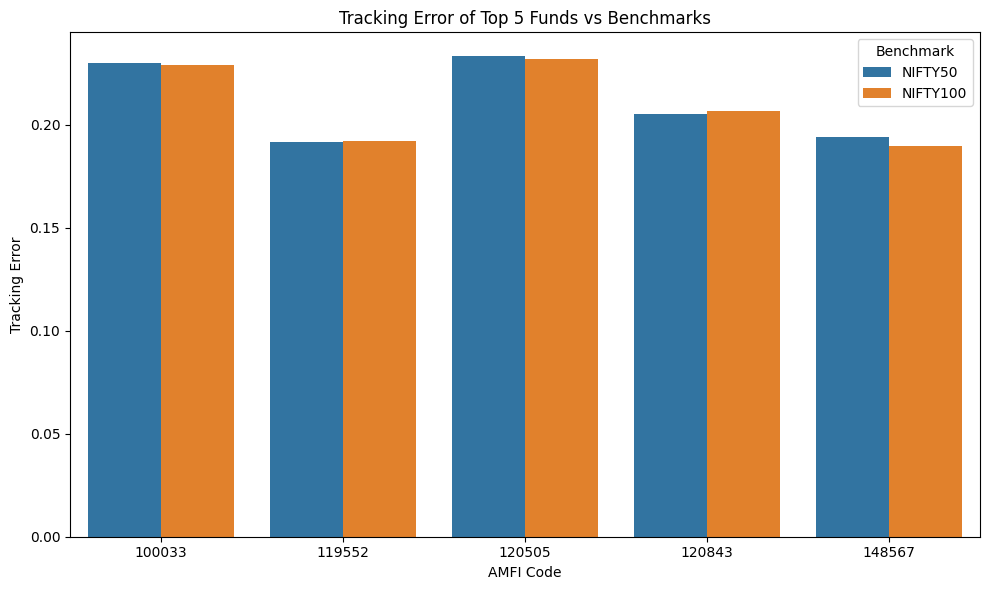

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tracking_df,
    x="amfi_code",
    y="Tracking Error",
    hue="Benchmark"
)

plt.title("Tracking Error of Top 5 Funds vs Benchmarks")
plt.xlabel("AMFI Code")
plt.ylabel("Tracking Error")

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png", dpi=300)

plt.show()

### Insight 8

- Tracking Error was calculated for the top 5 mutual fund schemes against NIFTY50 and NIFTY100.
- Lower Tracking Error indicates that a fund closely follows its benchmark index.
- Higher Tracking Error suggests greater deviation from benchmark performance.
- The comparison chart helps evaluate how consistently each fund tracks the selected market indices.